In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from SynOmics.metrics.narrow_utility.DGE import GCSAnalyzer
from pathlib import Path  
import matplotlib.image as mpimg
from matplotlib import gridspec

*******0*******


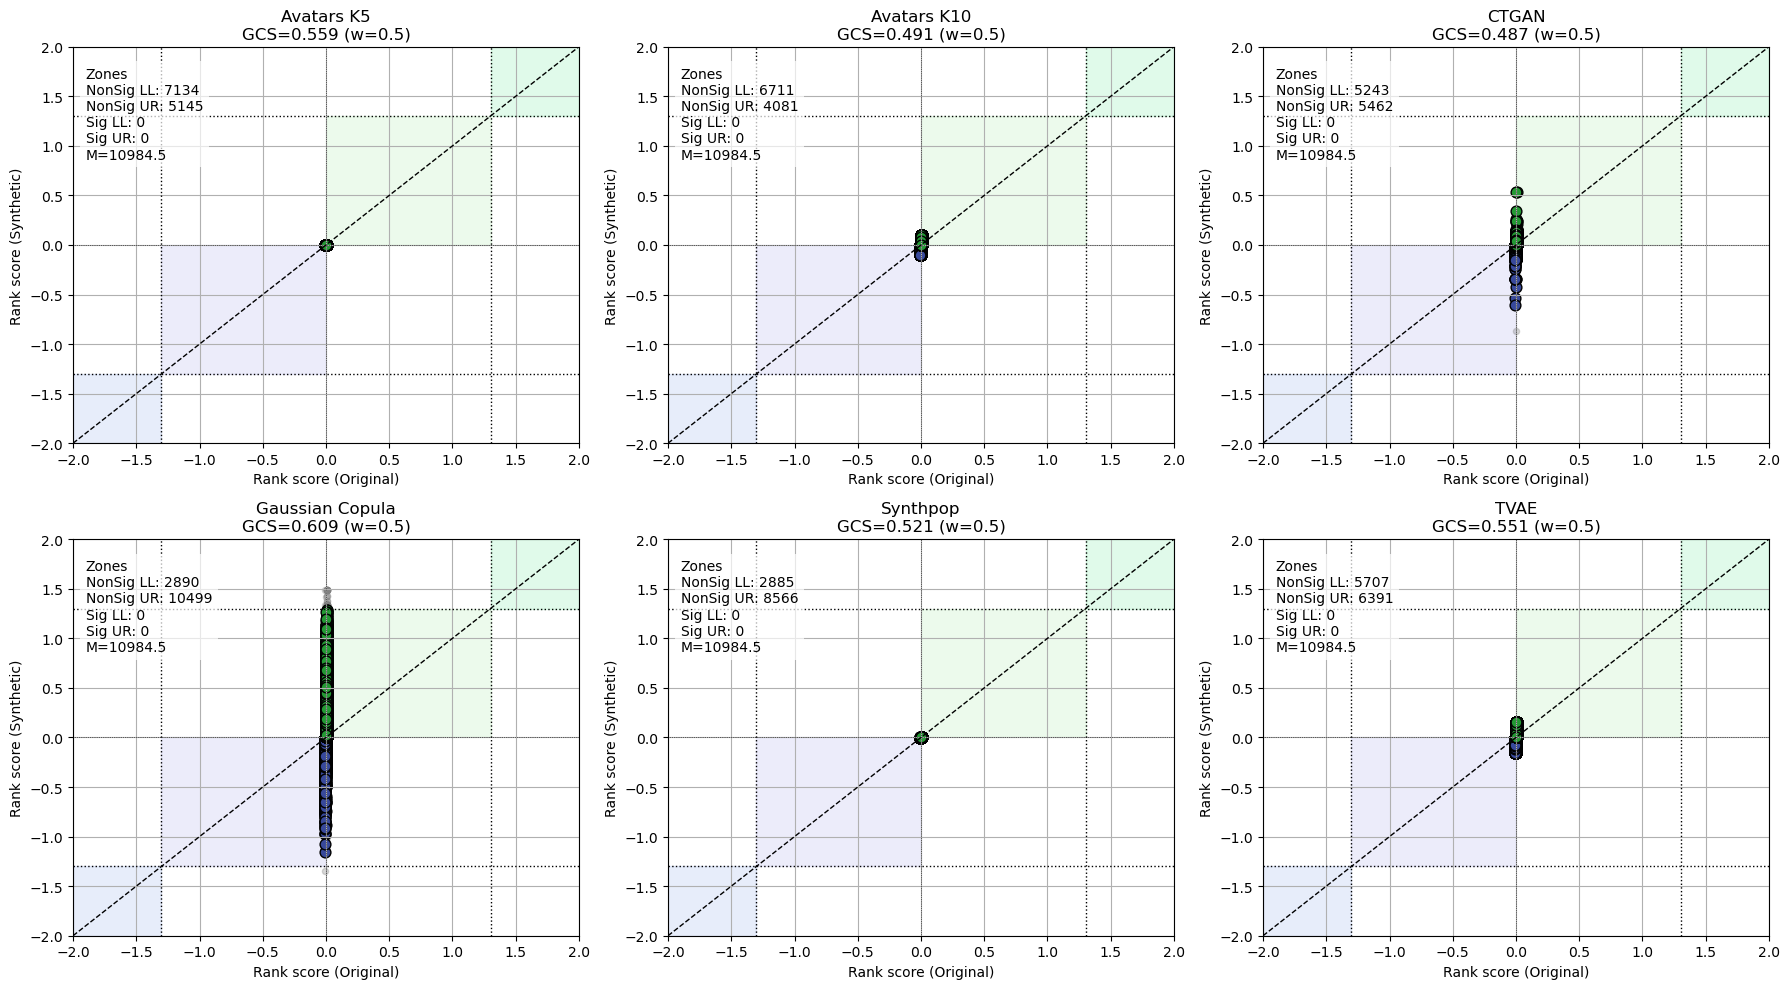

*******1*******


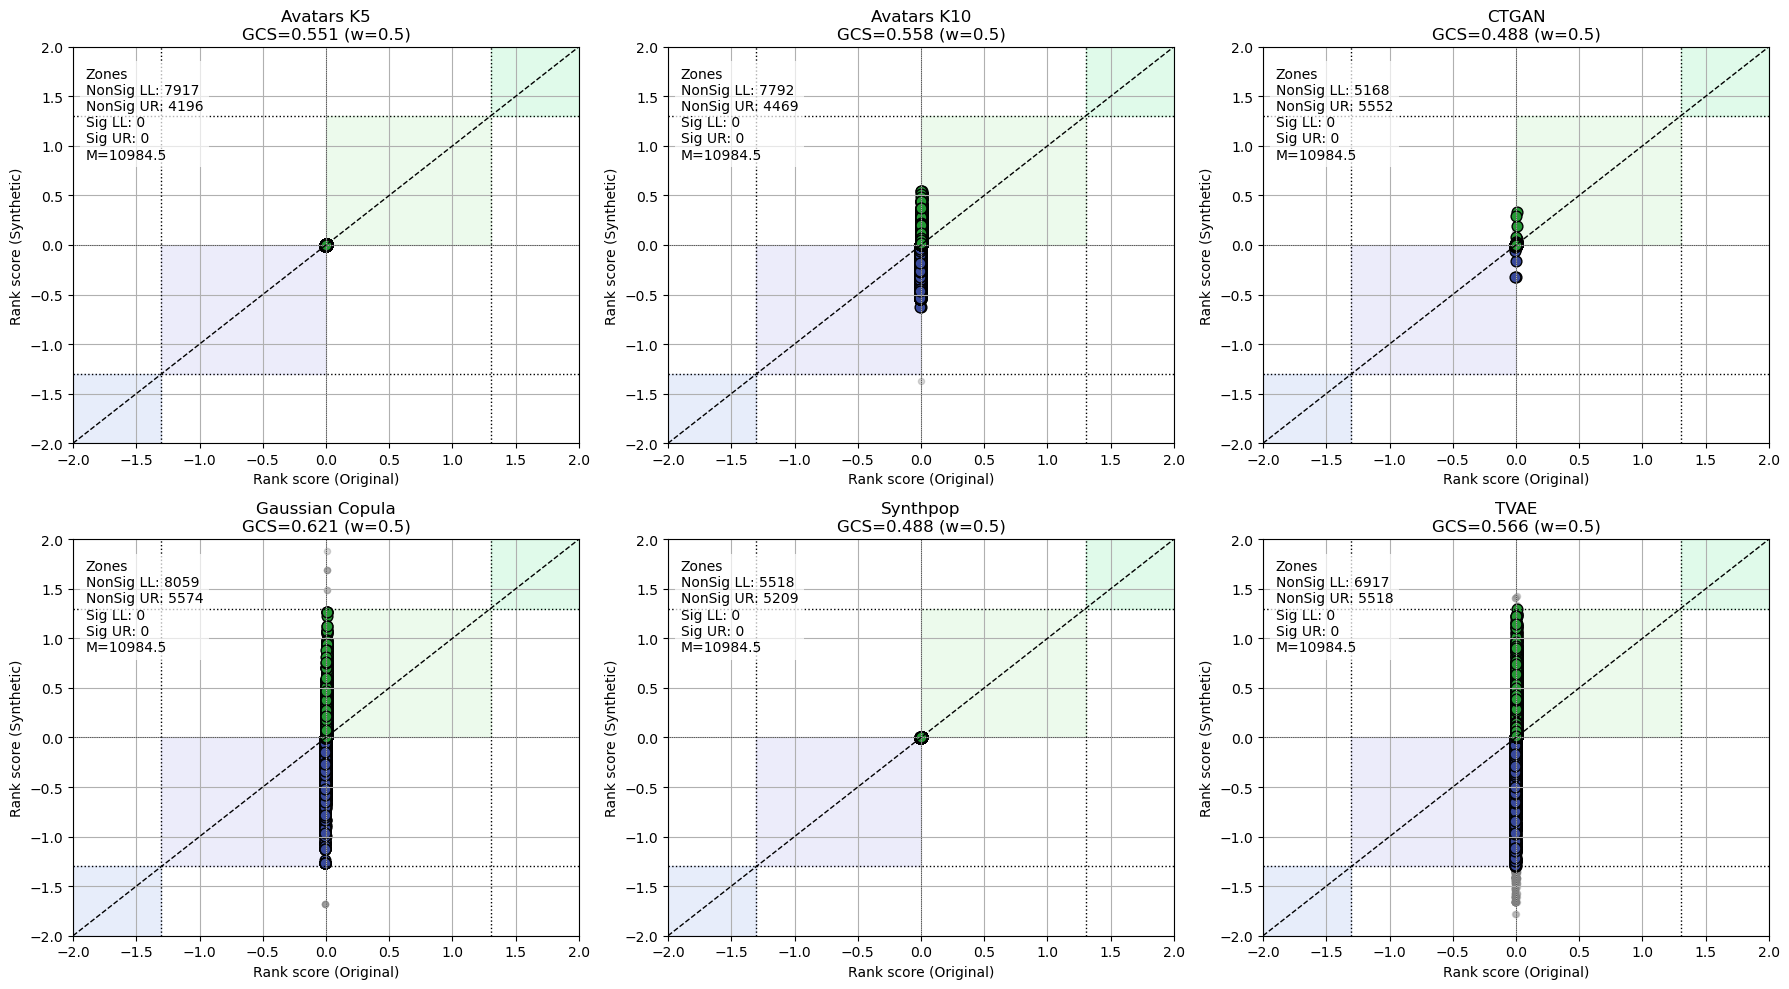

*******2*******


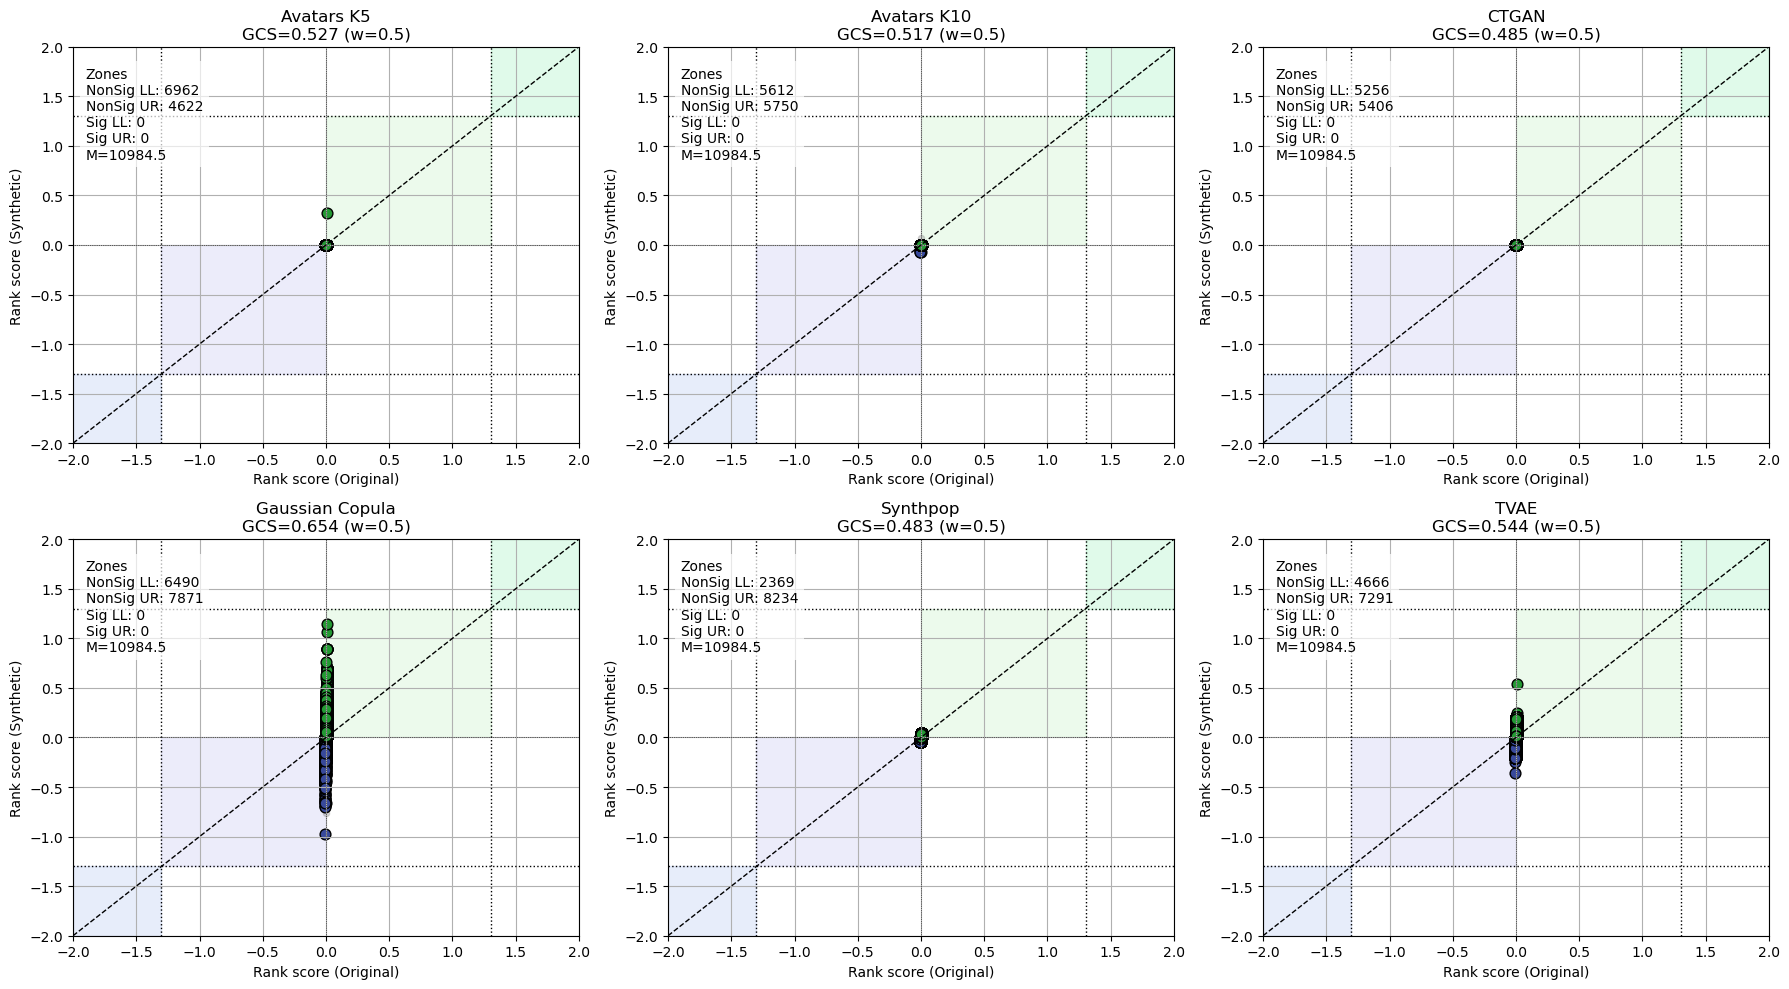

*******3*******


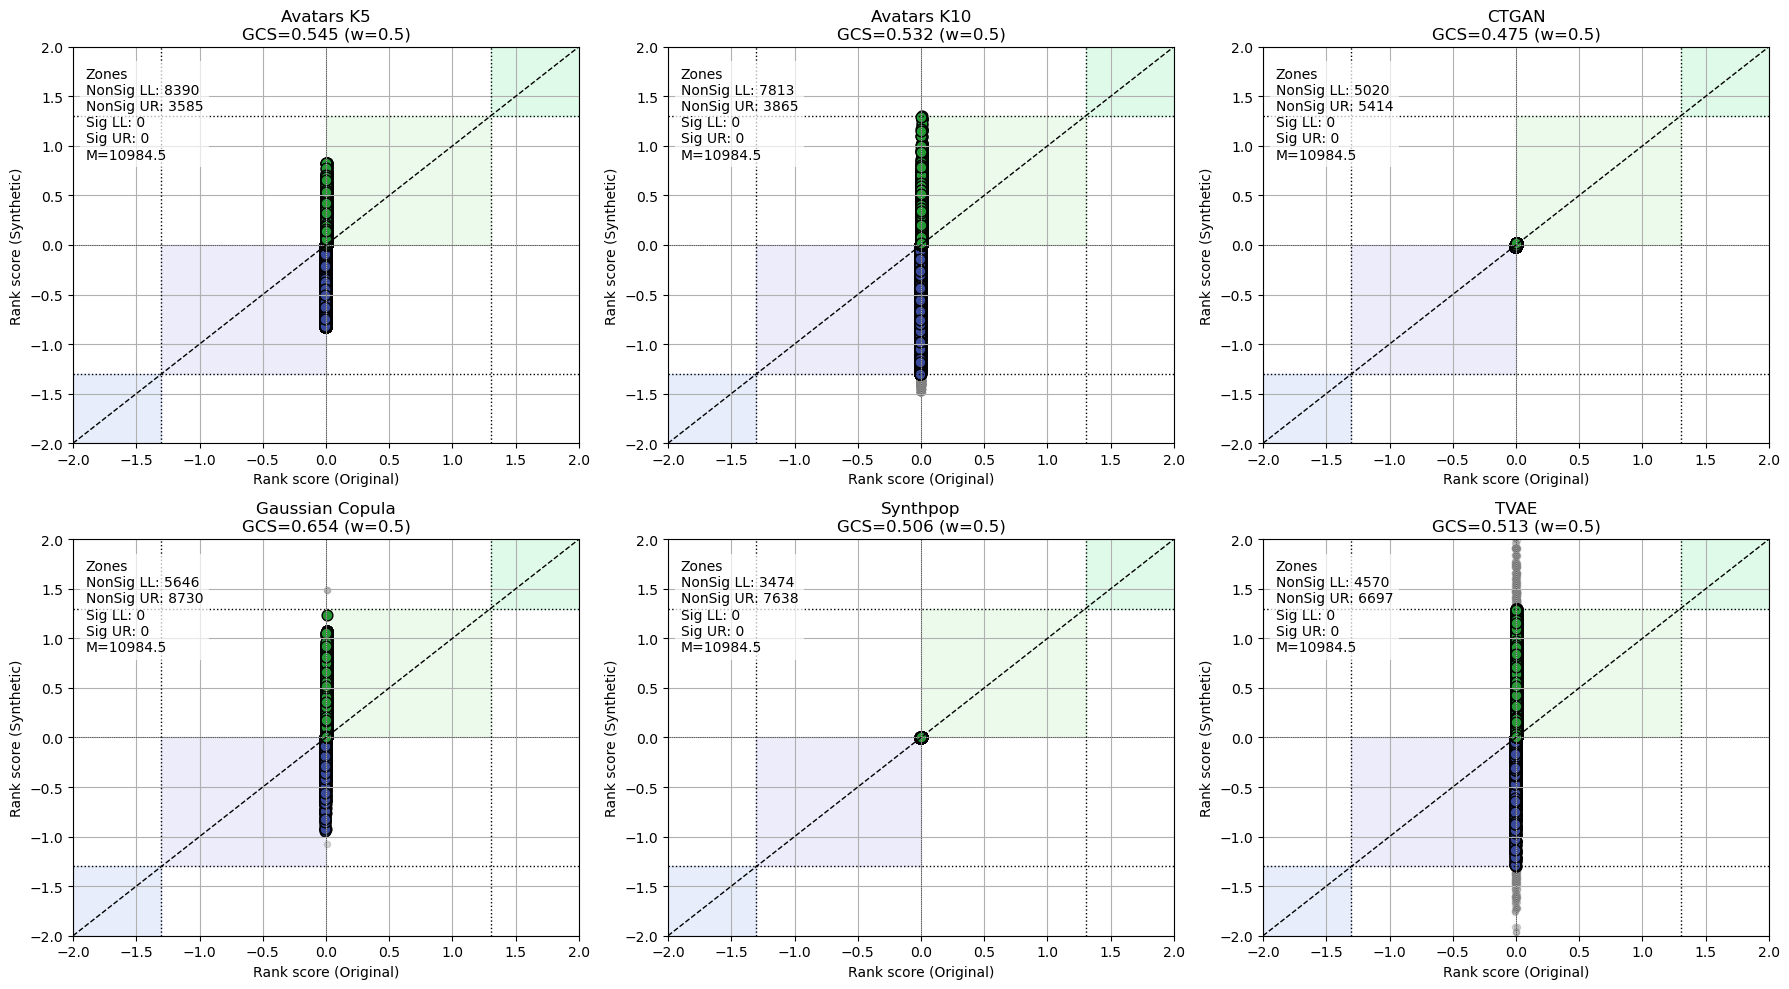

*******42*******


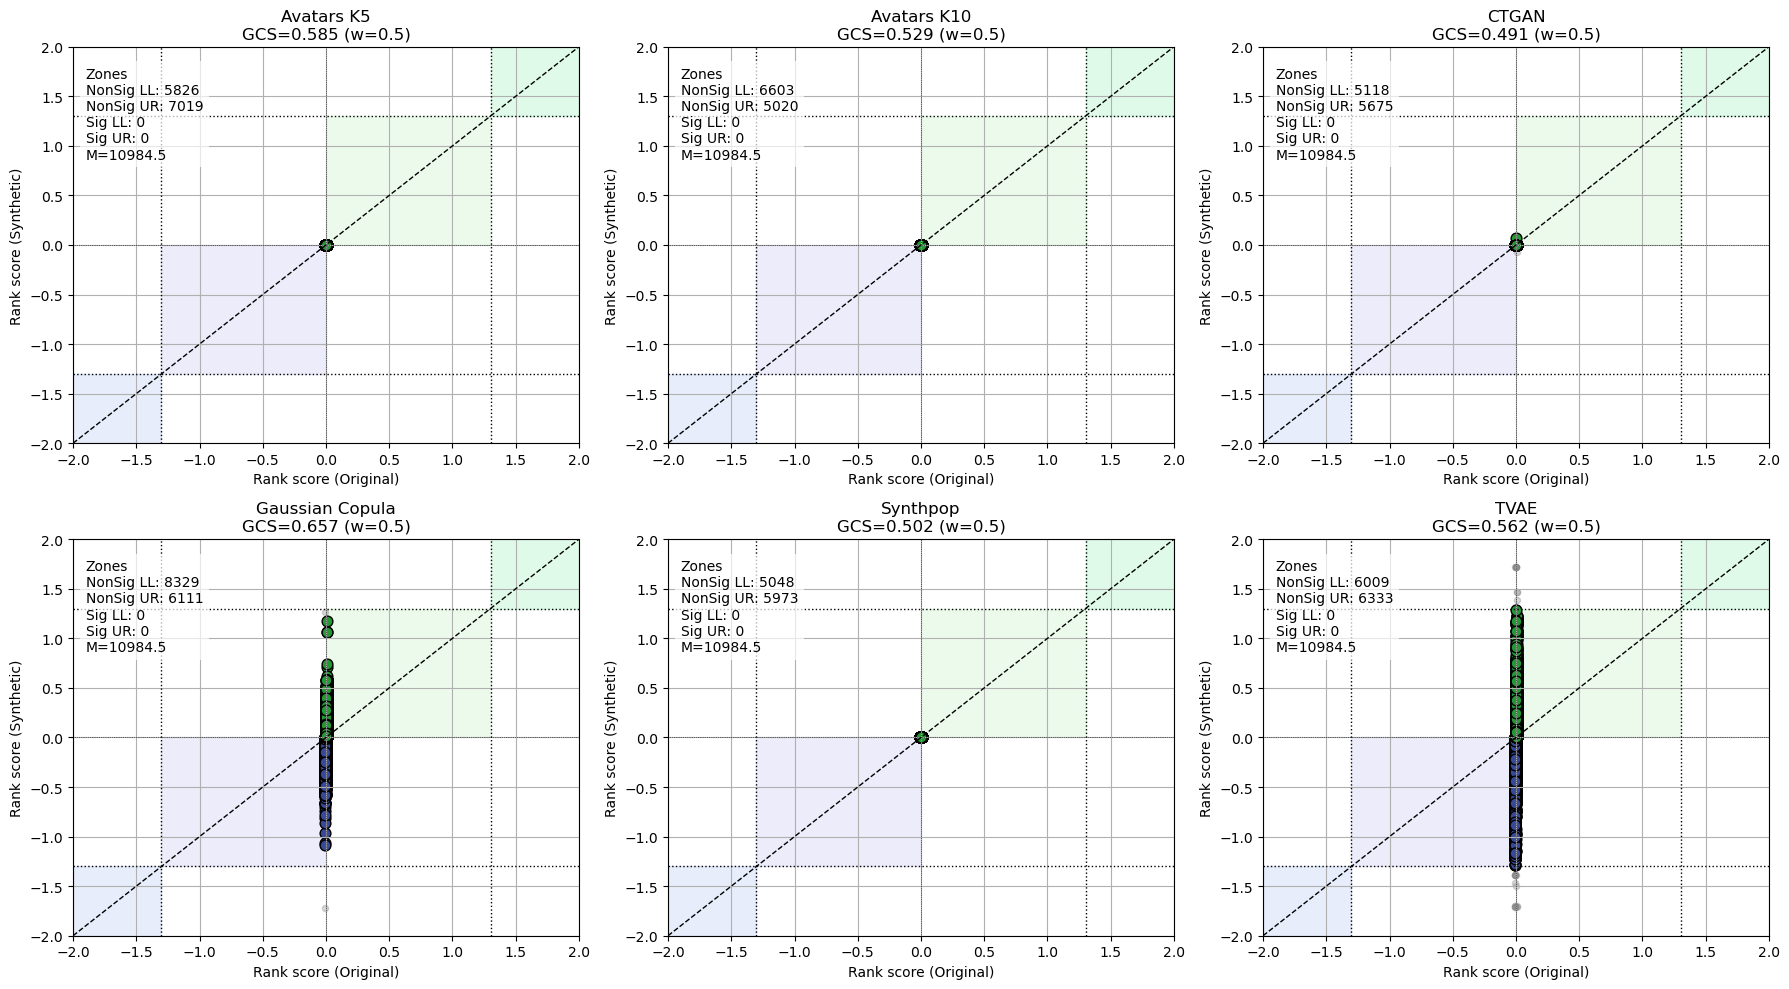

GCS scores across seeds:
Avatars K5: 0.5534707997633028 +/- 0.01878541091990838
Avatars K10: 0.5254312895443579 +/- 0.021705405563417886
CTGAN: 0.4853566389002685 +/- 0.005550846450295128
Gaussian Copula: 0.6390732395648413 +/- 0.020001169354083494
Synthpop: 0.49992261823478534 +/- 0.013610692828099074
TVAE: 0.547125495015704 +/- 0.018800603528847333


In [2]:
seeds = [0, 1, 2, 3, 42]
gcs_scores_across_seeds = {}

for seed in seeds:
    print(f"*******{seed}*******")

    dataset_dict = {
        'Avatars K5': f'CRPR_PD/Seed_{seed}/DGE_avatarsk5_{seed}.csv',
        'Avatars K10': f'CRPR_PD/Seed_{seed}/DGE_avatarsk10_{seed}.csv',
        'CTGAN': f'CRPR_PD/Seed_{seed}/DGE_ctgan_{seed}.csv',
        'Gaussian Copula': f'CRPR_PD/Seed_{seed}/DGE_gaussiancopula_{seed}.csv',
        'Synthpop': f'CRPR_PD/Seed_{seed}/DGE_synthpop_{seed}.csv',
        'TVAE': f'CRPR_PD/Seed_{seed}/DGE_tvae_{seed}.csv',
    }
    ori_path = f'CRPR_PD/Seed_{seed}/DGE_Origin.csv'

    analyzer = GCSAnalyzer(
        term_col="Gene",
        nes_col="Log2FC",
        q_col="Q_value",
        seed=42,
        q_thr=0.05,
        w=0.5,
    )

    fig, gcs_dict = analyzer.plot_gsea_datasets(
        ori_path=ori_path,
        dataset_dict=dataset_dict,
        figsize=(18, 10),
    )

    fig.savefig(f"GCS/Seed_{seed}.png", dpi=300, bbox_inches="tight")

    for tool, gcs in gcs_dict.items():
        if tool not in gcs_scores_across_seeds:
            gcs_scores_across_seeds[tool] = []
        gcs_scores_across_seeds[tool].append(gcs)

    gcs_across_seed_df = pd.DataFrame(gcs_scores_across_seeds)
    # gcs_across_seed_df.to_csv("GCS/gcs_score.csv", index=False)

print("GCS scores across seeds:")
for tool, gcs_list in gcs_scores_across_seeds.items():
    print(f"{tool}: {np.mean(gcs_list)} +/- {np.std(gcs_list)}")

/tmp/ipykernel_351315/3210860901.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


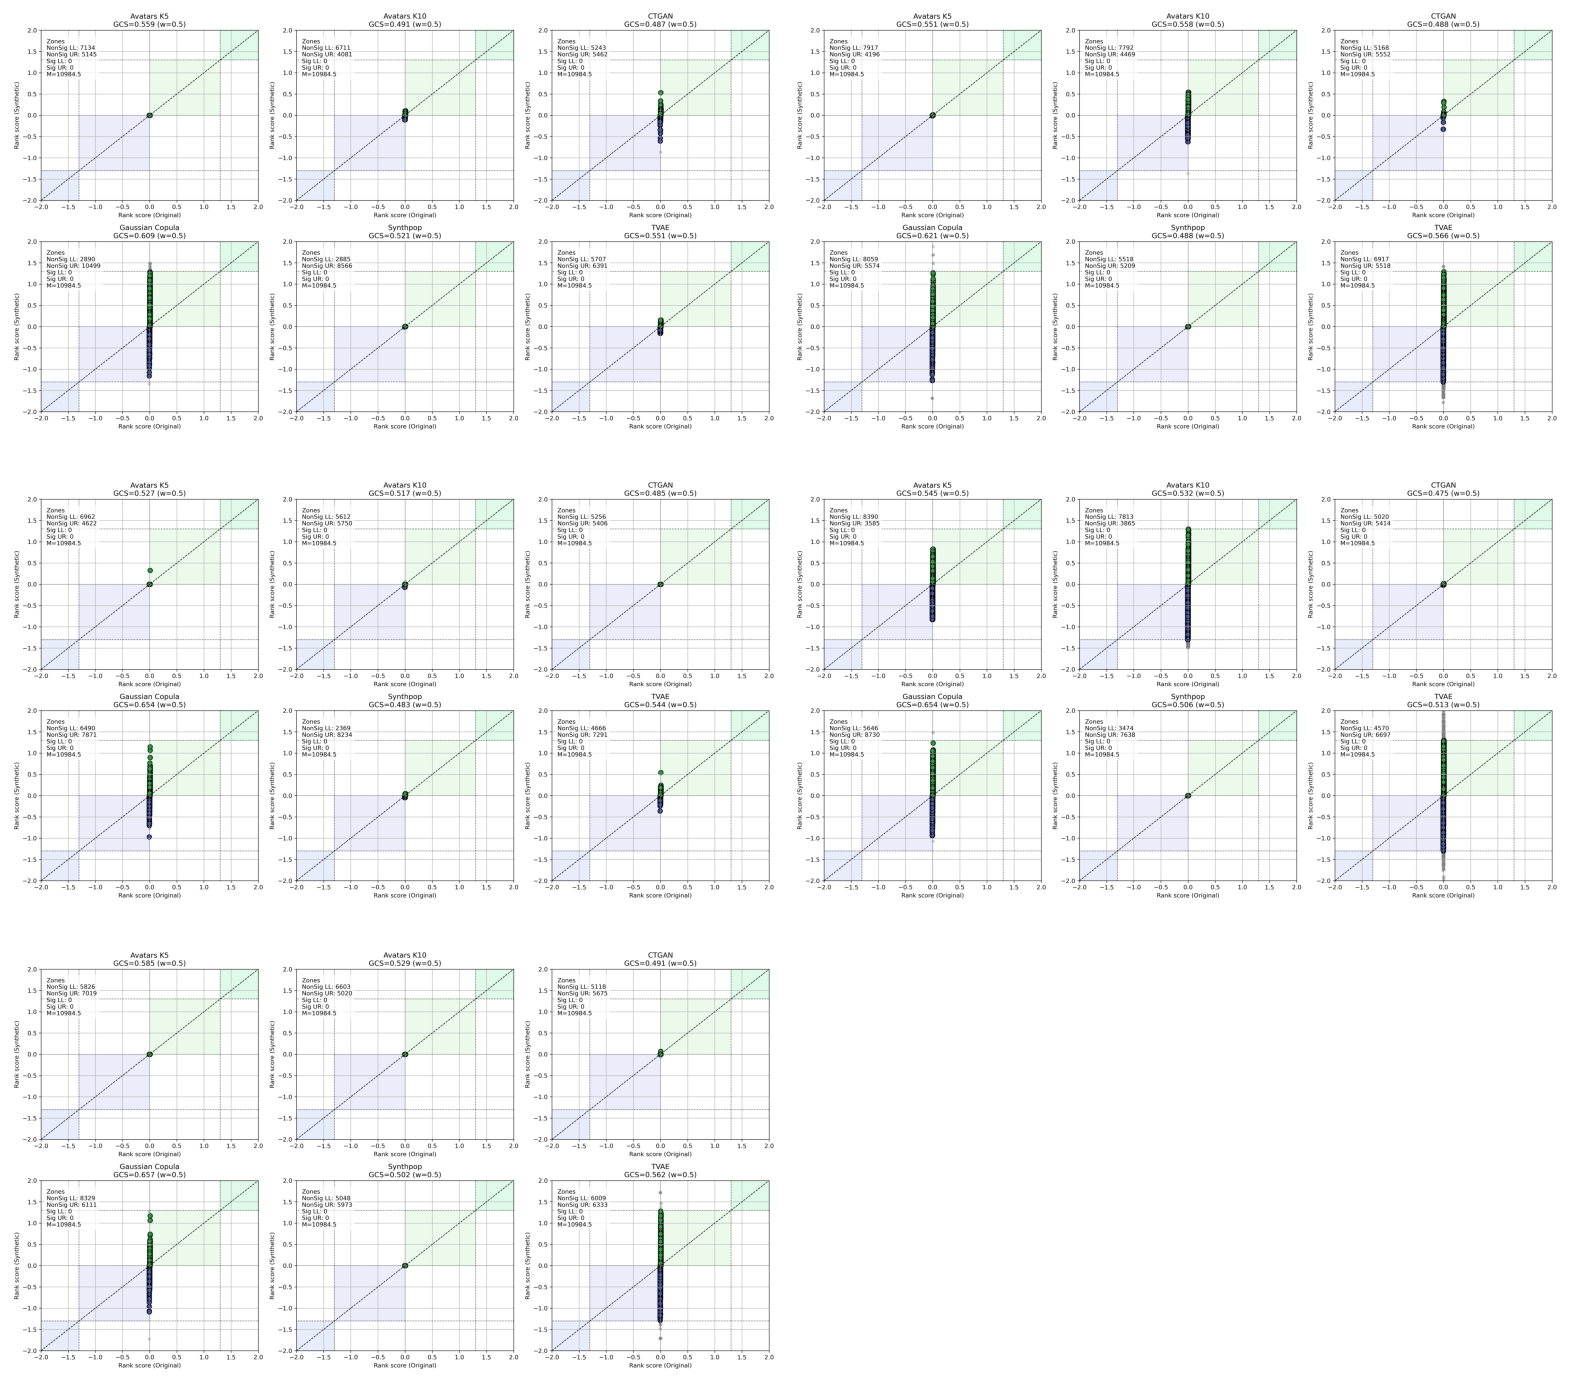

In [3]:
fig = plt.figure(figsize=(20, 18))

n_rows = 3
n_cols = 2
gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    wspace=0.02,
    hspace=0.05
)

def show_img(ax, path):
    try:
        img = mpimg.imread(path)
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, "Image Not Found", ha='center')
    ax.axis("off")


for i, seed in enumerate(seeds):
    
    row = i // n_cols  
    col = i % n_cols  
    
    path = f"GCS/Seed_{seed}.png"
    ax = fig.add_subplot(gs[row, col])
    show_img(ax, path)

if len(seeds) < n_rows * n_cols:
    for j in range(len(seeds), n_rows * n_cols):
        ax_empty = fig.add_subplot(gs[j // n_cols, j % n_cols])
        ax_empty.axis("off")

plt.tight_layout()
fig.savefig("GCS/Combined_2x3_images.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_351315/4103034485.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_351315/4103034485.py:16: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


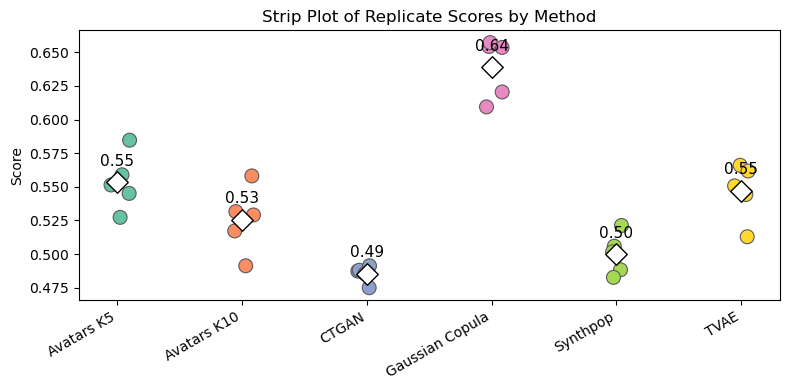

In [4]:
score_dict = gcs_scores_across_seeds

# Convert to long DataFrame
rows = []
for method, scores in score_dict.items():
    for score in scores:
        rows.append({'Method': method, 'Score': score})

df_long = pd.DataFrame(rows)

# Order for aesthetics (optional, or sorted by mean)
method_order = list(score_dict.keys())

plt.figure(figsize=(8, 4))

sns.stripplot(
    x='Method', 
    y='Score', 
    data=df_long, 
    order=method_order,
    size=10, 
    jitter=True, 
    palette='Set2', 
    edgecolor='gray', 
    linewidth=0.8,
)

# Show mean of each method as diamond marker
means = df_long.groupby("Method")["Score"].mean().reindex(method_order)
for i, mu in enumerate(means):
    plt.scatter(i, mu, marker='D', color='white', edgecolor='black', s=120, zorder=10, label=None)
    plt.text(i, mu + 0.01, f"{mu:.2f}", ha="center", va="bottom", fontsize=11, color="black")

plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=30, ha='right')
plt.title("Strip Plot of Replicate Scores by Method")
plt.tight_layout()
plt.show()